<a href="https://colab.research.google.com/github/pranita2113/EE_machine_learning/blob/main/Task10_EE514.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None
    def forward(self, input):
        pass
    def backward(self,output_gradient, learning_rate):
        pass

In [3]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)
    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias
    def backward(self, output_gradient, learning_rate):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient
        return input_gradient

In [5]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))
def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)


In [6]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime
    def forward(self, input):
        self.input = input
        return self.activation(self.input)
    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [7]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)
        def tanh_prime(x):
            return 1- np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)
class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))
        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)
        super().__init__(sigmoid, sigmoid_prime)

In [8]:
import math

In [10]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x
        def linear_prime(x):
            return 1
        super().__init__(linear, linear_prime)

In [12]:
X = np.linspace(-3, 3, 61)
Y = [math.sin(p) for p in X]
network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]
epochs = 50
learning_rate = 0.1
errorlist = []
for e in range(epochs):
    error = 0
    for x, y in zip(X, Y):
        output = x
        for layer in network:
            output = layer.forward(output)
        error += mse(y, output)
        grad = mse_prime(y, output)
        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=1.4419547590693411
2/50, error=0.07670285438499405
3/50, error=0.024948490226069386
4/50, error=0.024311572320206712
5/50, error=0.15254856016117121
6/50, error=0.06154428491157774
7/50, error=0.41802553810256415
8/50, error=0.11080156315856252
9/50, error=0.037006167146103254
10/50, error=0.0411818284791369
11/50, error=0.04241251100148539
12/50, error=0.034516107380599126
13/50, error=0.21687937507134897
14/50, error=0.013186525551437409
15/50, error=0.007700342054683209
16/50, error=0.04869811133814623
17/50, error=0.01324774363726988
18/50, error=0.04446433256911157
19/50, error=0.009893331477206082
20/50, error=0.047719811026007086
21/50, error=0.01796464566962305
22/50, error=0.031538107958284115
23/50, error=0.05320694897804202
24/50, error=0.051755630835603465
25/50, error=0.05073779526284172
26/50, error=0.03670136741914349
27/50, error=0.04488472057741411
28/50, error=0.0329300514781164
29/50, error=0.04185618821759425
30/50, error=0.04626366099553058
31/50, error

In [14]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output = layer.forward(output)
    actual_Y.append(output[0])
print(output)

[[0.03694205]]


In [15]:
import matplotlib.pyplot as plt

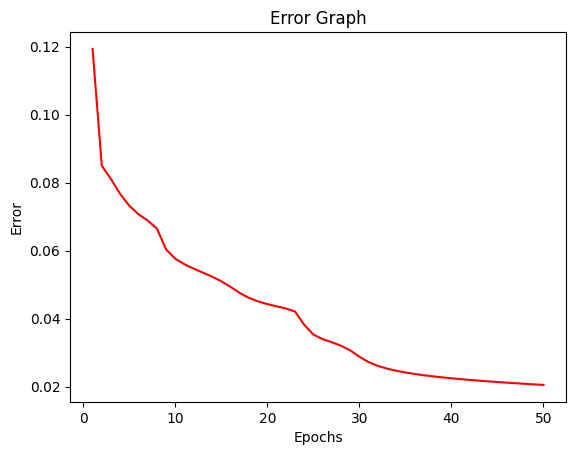

In [33]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [19]:
def preprocess_data(x, y, limit):
    x = x.reshape(x.shape[0], 28 * 28, 1)
    x = x.astype("float32") / 255
    y = to_categorical(y)
    y = y.reshape(y.shape[0], 10, 1)
    return x[:limit], y[:limit]

In [21]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]
epochs = 50
learning_rate = 0.1
errorlist = []
for e in range(epochs):
    error = 0
    for x, y in zip(x_train, y_train):
        output = x
        for layer in network:
            output = layer.forward(output)
        error += mse(y, output)
        grad = mse_prime(y, output)
        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x_train)
    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=0.11930102113602611
2/50, error=0.08496232609163579
3/50, error=0.08103520190085663
4/50, error=0.07663982787570878
5/50, error=0.07315772685177048
6/50, error=0.07066165627578837
7/50, error=0.06881787226148928
8/50, error=0.06643223523399978
9/50, error=0.06029030745186926
10/50, error=0.05757125342590892
11/50, error=0.05595499581972016
12/50, error=0.05468446234779857
13/50, error=0.05350764147675103
14/50, error=0.05231932191057307
15/50, error=0.050970492254447046
16/50, error=0.04932338113942624
17/50, error=0.04752889586054127
18/50, error=0.046095696285494606
19/50, error=0.045055983051434566
20/50, error=0.04426073731182842
21/50, error=0.04359629756023964
22/50, error=0.042978966808703584
23/50, error=0.04208821533395708
24/50, error=0.03818156245452408
25/50, error=0.035288804132009854
26/50, error=0.033975013178309664
27/50, error=0.0330482331605316
28/50, error=0.03202628662547403
29/50, error=0.030647430124125304
30/50, error=0.028787528327767934
31/50, error

In [26]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [27]:
!pip install simple_colors
import simple_colors

In [29]:
correct = 0
for x, y in zip(x_test, y_test):
    output = predict(network, x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))
        accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 5 	true: 9
pred: 2 	true: 5
pred: 4 	true: 9
pred: 0 	true: 0
pred: 2 	true: 6
pred: 9 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.4
Correct: 16


In [31]:
error = errorlist
X = list(range(1, len(errorlist) + 1))

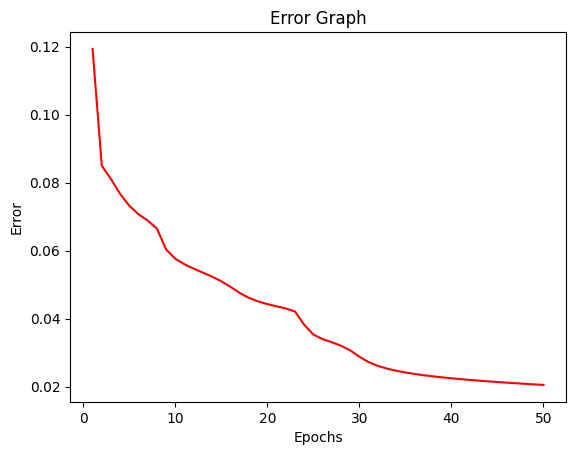

In [32]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()